# Student Performance Data Analysis

## Objective

The goal of this project is to perform data exploration and cleaning on a student performance dataset. The analysis focuses on understanding score distributions, identifying data quality issues, and extracting insights that can help educators improve student outcomes.

## 1. Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)



## 2. Load Dataset

In [ ]:
df = pd.read_csv("../data/StudentsPerformance.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Preview

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 4. Dataset Dimensions

In [8]:
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 1000
Number of Columns : 8


## 5. Dataset Information

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 6. Missing Values Analysis

Before performing any analysis, it is important to check whether the dataset contains missing values. Missing values can affect statistical summaries and model performance.

In [10]:
missing_values = df.isnull().sum()

missing_values

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [11]:
print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


## 7. Duplicate Record Analysis

Duplicate records can introduce bias in data analysis. Therefore, duplicate entries are checked before proceeding further.

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [13]:
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

No duplicate records found.


## 8. Column Name Standardization

Column names are standardized to improve readability and maintain consistency during analysis.

In [14]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

### Column Name Standardization

The original dataset contained column names with spaces, which can make data manipulation less convenient. Column names were converted to lowercase and spaces were replaced with underscores to improve consistency and readability.

In [15]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

## 9. Score Distribution Analysis

Understanding score distributions helps identify overall student performance trends and detect whether scores are concentrated around specific ranges.

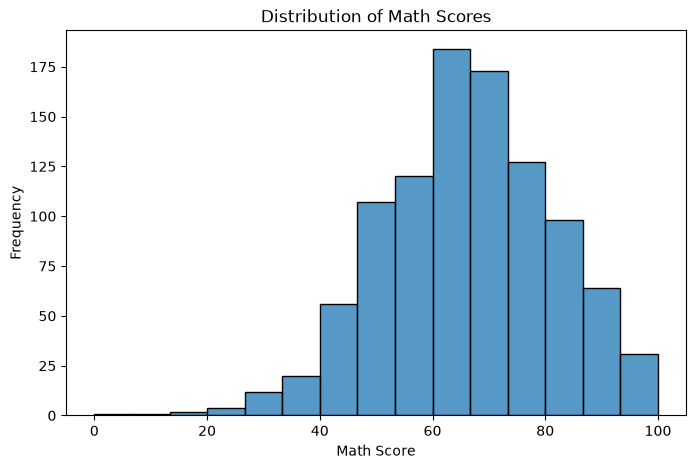

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df["math_score"], bins=15)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.show()